# 📈 Polynomial Regression
---


## 📑 Table of Contents
1. [Introduction & Definition](#1.-Introduction-&-Definition)
2. [How It Works — Math & Intuition](#2.-How-It-Works-—-Math-&-Intuition)
3. [When To Use](#3.-When-To-Use)
4. [Pros & Cons](#4.-Pros-&-Cons)
5. [Dataset Upload & Exploration](#5.-Dataset-Upload-&-Exploration)
   - 5.1 Import Libraries
   - 5.2 Load Auto MPG Dataset
   - 5.3 Exploratory Data Analysis (EDA)
   - 5.4 Preprocessing & Feature Engineering
6. [Training the Model](#6.-Training-the-Model)
   - 6.1 Train/Validation/Test Split
   - 6.2 Fit the Model (Pipeline Architecture)
7. [Validation](#7.-Validation)
   - 7.1 Cross-Validation
   - 7.2 Validation Metrics
8. [Testing & Diagnostics](#8.-Testing-&-Diagnostics)
   - 8.1 Final Test Set Evaluation
   - 8.2 The Extrapolation Catastrophe
9. [Optimization / Hyperparameter Tuning](#9.-Optimization-/-Hyperparameter-Tuning)
   - 9.1 GridSearchCV for Optimal Polynomial Degree
   - 9.2 Best Parameters & Retrain
10. [Visualization: The Bias-Variance Tradeoff](#10.-Visualization:-The-Bias-Variance-Tradeoff)
11. [Tips & Tricks Summary](#11.-Tips-&-Tricks-Summary)
12. [Conclusion](#12.-Conclusion)


## 1. Introduction & Definition

**Polynomial Regression** represents a critical conceptual leap: recognising that a model can remain **linear in its parameters** while being completely **non-linear in its features**. This unlocks the ability to model curves, parabolas, and oscillations using the mathematically clean guarantees of Ordinary Least Squares (OLS).

Standard Linear Regression fits a straight line:
$$y = w_0 + w_1 x$$

Polynomial Regression of degree $d$ fits:
$$y = w_0 + w_1 x + w_2 x^2 + w_3 x^3 + \dots + w_d x^d + \epsilon$$

### 🧠 The Core Insight: Why Is It Still "Linear"?
Define the **basis expansion** (feature map) $\phi(x) = [1, x, x^2, \dots, x^d]^T$. Then:

$$y = \mathbf{w}^T \phi(x)$$

This is **linear in $\mathbf{w}$** — the parameters enter linearly. The MSE loss surface remains a strictly convex paraboloid with a **unique global minimum**. All OLS theory (Normal Equation, Gauss-Markov, MLE equivalence) applies unchanged.

### 📐 The Vandermonde Matrix
Applying $\phi$ to all $N$ training points produces the **Vandermonde Matrix** $\mathbf{\Phi}$:

$$\mathbf{\Phi} = \begin{bmatrix}
1 & x^{(1)} & (x^{(1)})^2 & \dots & (x^{(1)})^d \\\\
1 & x^{(2)} & (x^{(2)})^2 & \dots & (x^{(2)})^d \\\\
\vdots & \vdots & \vdots & \ddots & \vdots \\\\
1 & x^{(N)} & (x^{(N)})^2 & \dots & (x^{(N)})^d
\end{bmatrix}$$

We then apply the Normal Equation: $\hat{\mathbf{w}}^* = (\mathbf{\Phi}^T\mathbf{\Phi})^{-1}\mathbf{\Phi}^T\mathbf{y}$.


## 2. How It Works — Math & Intuition

### Step 1: Basis Expansion and the Vandermonde Matrix
The transformation $\phi: \mathbb{R} \to \mathbb{R}^{d+1}$ maps each scalar $x$ into a $(d+1)$-dimensional feature vector. The resulting design matrix is the **Vandermonde matrix** — a classical structure in numerical analysis. Once built, we solve $\hat{\mathbf{w}}^* = (\mathbf{\Phi}^T\mathbf{\Phi})^{-1}\mathbf{\Phi}^T\mathbf{y}$.

### Step 2: The Bias-Variance Tradeoff (The Central Problem)
The expected test error decomposes as:

$$E[(y - \hat{f}(x))^2] = \underbrace{\text{Bias}[\hat{f}(x)]^2}_{\text{Underfitting}} + \underbrace{\text{Var}[\hat{f}(x)]}_{\text{Overfitting}} + \underbrace{\sigma^2}_{\text{Irreducible Noise}}$$

| Degree $d$ | Bias | Variance | Behaviour |
| :---: | :---: | :---: | :--- |
| $d=1$ | High | Low | Underfits: rigid line ignores the curve |
| $d\approx3$–5 | Low | Low | Ideal: tracks true function smoothly |
| $d=15$ | Low | **Very High** | Overfits: memorises every noisy point |

### Step 3: Runge's Phenomenon
In numerical analysis, interpolating equispaced data with a high-degree polynomial causes **exponentially growing oscillations near the boundary** of the interval — this is **Runge's Phenomenon**. Even near-zero training error does not prevent catastrophic, oscillating predictions at the edges and completely wrong extrapolations beyond training range.

### Step 4: The Condition Number Explosion — Why Scaling is Mandatory
If $x = 10$, then $x^5 = 100{,}000$. The Vandermonde columns have vastly different magnitudes. This causes the **condition number** $\kappa(\mathbf{\Phi}^T\mathbf{\Phi}) = \lambda_{max}/\lambda_{min}$ to explode. A huge condition number means:
- Matrix inversion introduces catastrophic floating-point rounding errors.
- Gradient Descent requires an astronomically small learning rate.

**Solution:** Apply `StandardScaler` to $x$ *before* computing polynomial features. This collapses the condition number from billions to a manageable range.

### Step 5: The Curse of Dimensionality (Multi-Feature Case)
For $p$ original features and degree $d$, the number of generated features is:
$$\binom{p+d}{d} = \frac{(p+d)!}{d!\,p!}$$

For $p=100$, $d=3$: **176,851 columns**. For $d=4$: **4.6 million columns**. Beyond degree 2–3, polynomial expansion in high dimensions is computationally infeasible.

**Alternative: The Kernel Trick.** A Polynomial Kernel in SVR/Ridge implicitly computes dot products in the high-dimensional space without materialising $\mathbf{\Phi}$, bypassing the memory explosion entirely.


## 3. When To Use

- **Curvilinear Data:** When a scatter plot of your data shows a distinct curve (e.g., U-shape, exponential growth) rather than a straight line.
- **Physical/Scientific Phenomena:** Many laws of physics and biology (like gravity, $F = G \frac{m_1 m_2}{r^2}$, or viral spread) are inherently polynomial.
- **Feature Synergies (Interactions):** Sometimes the target depends not just on $X_1$ and $X_2$, but on them happening *together*. `PolynomialFeatures` generates cross-terms like $X_1 X_2$. For example, the likelihood of buying a house might depend on (Income $\times$ Age).


### The Extrapolation Catastrophe
Our model was trained on horsepower values strictly up to about 230. What if we try to predict the MPG of a hypothetical 400 HP supercar? Let's force the polynomial model to predict what happens outside its training zone.


## 5. Dataset Upload & Exploration

To perfectly demonstrate the nuances of Polynomial Regression (especially overfitting and extrapolation), we will use the real-world **Auto MPG dataset**. We will look at the relationship between a car's **Horsepower** and its **Miles Per Gallon (MPG)**. As horsepower increases, MPG generally drops, but the relationship is not a perfectly straight line.

In [1]:
# ============================================================
# SECTION 5.1 — IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')


In [2]:
# ============================================================
# SECTION 5.2 — LOAD AUTO MPG DATASET
# ============================================================

# Load the Auto MPG dataset from seaborn
df = sns.load_dataset('mpg')

# Drop rows where horsepower or mpg is missing
df = df.dropna(subset=['horsepower', 'mpg']).copy()

# For this focused demonstration, we will only use horsepower to predict mpg
X = df['horsepower'].values
y = df['mpg'].values

print(f"Dataset Shape: {df.shape}\n")

print("--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe())

print("\n--- First 5 Rows ---")
display(df.head())


Dataset Shape: (392, 9)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 30.6+ KB

--- Summary Statistics ---


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000



--- First 5 Rows ---


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


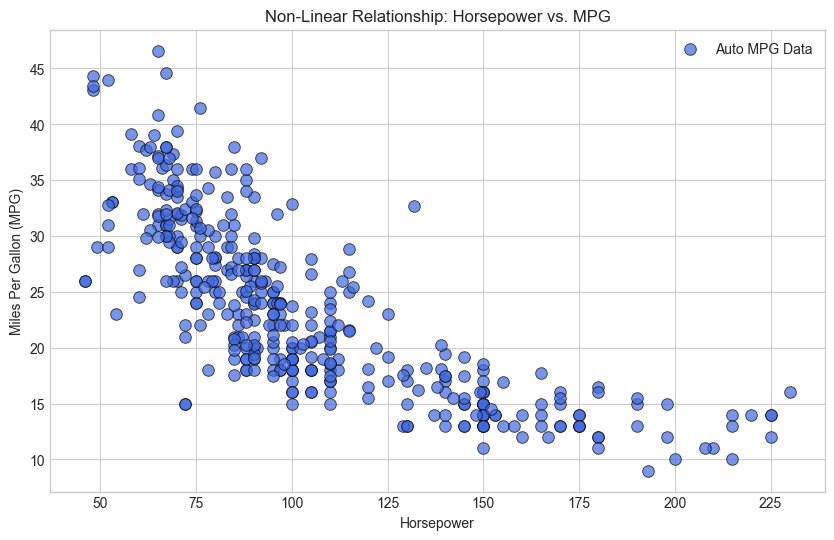

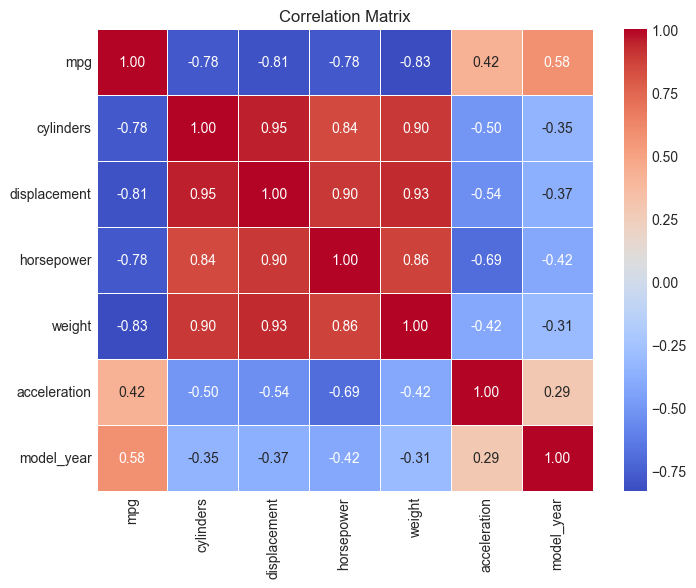

In [3]:
# ============================================================
# SECTION 5.3 — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
# 1. Feature vs Target Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='horsepower', y='mpg', data=df, color='royalblue', s=70, edgecolor='black', alpha=0.7, label="Auto MPG Data")

plt.title('Non-Linear Relationship: Horsepower vs. MPG')
plt.xlabel('Horsepower')
plt.ylabel('Miles Per Gallon (MPG)')
plt.legend()
plt.show()

# 2. Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


**Observation:** A standard Linear Regression (straight line) will clearly underfit here. As horsepower increases, MPG drops rapidly at first, but then the drop levels off for very high horsepower cars. The data follows a curve, meaning we need a polynomial model.

In [4]:
# ============================================================
# SECTION 5.4 — PREPROCESSING & FEATURE ENGINEERING
# ============================================================

# Scikit-Learn expects features to be a 2D matrix, so we reshape X
X_mat = X[:, np.newaxis]


## 6. Training the Model (The Pipeline Approach)

Because Polynomial Regression requires a sequential 3-step process (`Polynomial Expansion` $\rightarrow$ `StandardScaler` $\rightarrow$ `Linear Regression`), the professional way to code this in Scikit-Learn is by using a `Pipeline`. This ensures that we never accidentally leak data from the test set into the scaler or the polynomial generator.


In [5]:
# ============================================================
# SECTION 6.1 — TRAIN / VAL / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(X_mat, y, test_size=0.30, random_state=42)
print(f"Training Set: {X_train.shape}")
print(f"Test Set: {X_test.shape}")


Training Set: (274, 1)
Test Set: (118, 1)


In [6]:
# ============================================================
# SECTION 6.2 — FIT THE MODEL (Pipeline Architecture)
# ============================================================

# We start by testing a Degree 2 polynomial.
degree = 2

poly_pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
    ('std_scaler', StandardScaler()),
    ('lin_reg', LinearRegression())
])

poly_pipeline.fit(X_train, y_train)
print(f"Polynomial Pipeline (Degree {degree}) successfully fitted!")


Polynomial Pipeline (Degree 2) successfully fitted!


## 7. Validation


In [7]:
# ============================================================
# SECTION 7.1 & 7.2 — CROSS-VALIDATION & METRICS
# ============================================================

from sklearn.metrics import mean_absolute_error

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = cross_val_score(poly_pipeline, X_train, y_train, cv=kf, scoring='r2')
cv_rmse_scores = np.sqrt(-cross_val_score(poly_pipeline, X_train, y_train, cv=kf, scoring='neg_mean_squared_error'))

print(f"CV R2 Scores: {cv_r2_scores}")
print(f"Average CV R2: {cv_r2_scores.mean():.4f} (+/- {cv_r2_scores.std() * 2:.4f})")
print(f"Average CV RMSE: {cv_rmse_scores.mean():.4f} (+/- {cv_rmse_scores.std() * 2:.4f})")

# Let's also check the training error
y_train_pred = poly_pipeline.predict(X_train)
print(f"\nTraining RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"Training MAE:  {mean_absolute_error(y_train, y_train_pred):.4f}")
print(f"Training R2:   {r2_score(y_train, y_train_pred):.4f}")


CV R2 Scores: [0.60019353 0.67437023 0.77231694 0.60124214 0.81198022]
Average CV R2: 0.6920 (+/- 0.1739)
Average CV RMSE: 4.3467 (+/- 1.2368)

Training RMSE: 4.3112
Training MAE:  3.1917
Training R2:   0.7097


## 8. Testing & Diagnostics


In [8]:
# ============================================================
# SECTION 8.1 — FINAL TEST SET EVALUATION
# ============================================================

y_test_pred = poly_pipeline.predict(X_test)

print("--- Final Test Set Performance (Degree 2) ---")
print(f"MSE  (Mean Squared Error):      {mean_squared_error(y_test, y_test_pred):.4f}")
print(f"RMSE (Root Mean Squared Error): {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f"MAE  (Mean Absolute Error):     {mean_absolute_error(y_test, y_test_pred):.4f}")
print(f"R2 Score (Explained Variance):  {r2_score(y_test, y_test_pred):.4f}")


--- Final Test Set Performance (Degree 2) ---
MSE  (Mean Squared Error):      20.4517
RMSE (Root Mean Squared Error): 4.5224
MAE  (Mean Absolute Error):     3.4206
R2 Score (Explained Variance):  0.6134


### Residual Analysis & Diagnostics
Just like Linear Regression, we must check the residuals (errors) of our Polynomial model to ensure it meets the Gauss-Markov assumptions (Homoscedasticity and Normality of errors).


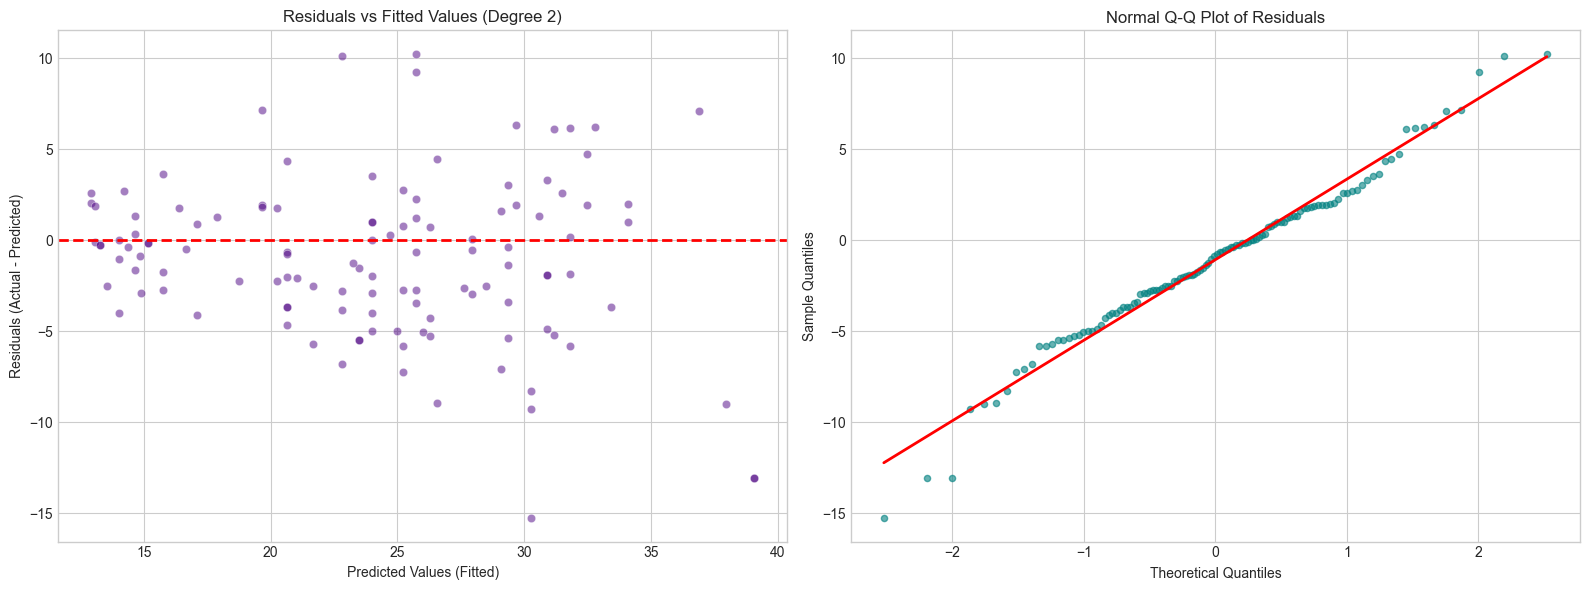

In [9]:
# ============================================================
# SECTION 8.1b — RESIDUAL ANALYSIS & DIAGNOSTICS
# ============================================================
import scipy.stats as stats

residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Residuals vs Predicted Values (Testing Homoscedasticity)
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.5, ax=axes[0], color='indigo')
axes[0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0].set_title('Residuals vs Fitted Values (Degree 2)')
axes[0].set_xlabel('Predicted Values (Fitted)')
axes[0].set_ylabel('Residuals (Actual - Predicted)')

# 2. Q-Q Plot (Testing Normality of Errors)
(osm, osr), (slope, intercept, _r) = stats.probplot(residuals, dist='norm')
axes[1].scatter(osm, osr, color='teal', alpha=0.6, s=20)
axes[1].plot(osm, slope * np.array(osm) + intercept, color='red', lw=2)
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')
axes[1].set_title('Normal Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()


### The Extrapolation Catastrophe
Our model was trained on horsepower values strictly up to about 230. What if we try to predict the MPG of a hypothetical 400 HP supercar? Let's force the polynomial model to predict what happens outside its training zone.


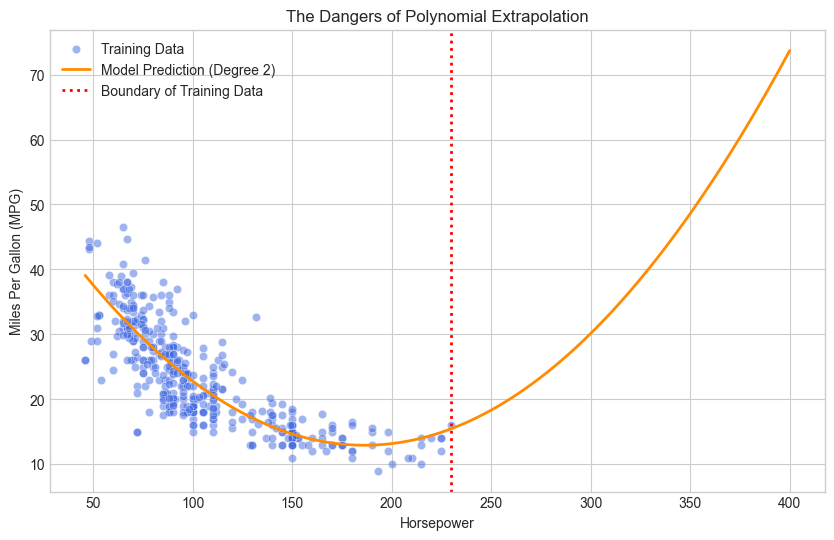

In [10]:
# ============================================================
# SECTION 8.2 — EXTRAPOLATION DIAGNOSTICS
# ============================================================

# Create data from min horsepower up to 400 (Pushing well past the training data limit of ~230)
X_extrapolate = np.linspace(df['horsepower'].min(), 400, 100)[:, np.newaxis]
y_extrapolate_pred = poly_pipeline.predict(X_extrapolate)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='horsepower', y='mpg', data=df, color='royalblue', alpha=0.5, label="Training Data")
plt.plot(X_extrapolate, y_extrapolate_pred, color='darkorange', lw=2, label="Model Prediction (Degree 2)")

plt.axvline(x=df['horsepower'].max(), color='red', linestyle=':', lw=2, label="Boundary of Training Data")
plt.title("The Dangers of Polynomial Extrapolation")
plt.xlabel("Horsepower")
plt.ylabel("Miles Per Gallon (MPG)")
plt.legend()
plt.show()


**Diagnostic Result:** Absolute failure! Because polynomials are governed by $x^d$, as soon as $x$ increases past the training boundary (e.g., predicting MPG for a 400 HP car), the $x^2$ term dominates and causes the parabola to shoot back upwards. The model predicts that a 400 HP car will have fantastic gas mileage, which is physically absurd. **Never use Polynomial Regression for extrapolation.**


## 9. Optimization / Hyperparameter Tuning

The polynomial degree $d$ is the critical hyperparameter controlling the Bias-Variance tradeoff. Choosing $d$ by eyeballing is unscientific; we use **Cross-Validation** to find the degree that minimises generalisation error — not training error.

### Why Not Just Minimise Training Error?
As $d$ increases, training RMSE **always decreases monotonically** (a degree-15 polynomial can pass through all 35 points with near-zero error). But CV error follows a **U-shape**:
- **Left of the U:** High bias (underfitting) — model too rigid.
- **Bottom of the U:** Optimal generalisation — the degree we want.
- **Right of the U:** High variance (overfitting) — model memorises noise.

GridSearchCV navigates this U-curve automatically, testing each candidate degree via $k$-fold cross-validation and returning the degree with the lowest average CV MSE.

### GridSearchCV Strategy
We wrap the full pipeline (PolyFeatures → Scaler → LinearRegression) in `GridSearchCV` with `scoring='neg_mean_squared_error'`. For each degree $d \in \{1, \dots, 15\}$:

1. Split training data into $k=5$ folds.
2. Train on $k-1$ folds, evaluate on the held-out fold.
3. Average the 5 MSE scores.
4. Select $d^*$ = degree with lowest average CV MSE.


In [11]:
# ============================================================
# SECTION 9.1 — GRIDSEARCHCV FOR OPTIMAL DEGREE
# ============================================================

pipeline_to_tune = Pipeline([
    ('poly_features', PolynomialFeatures(include_bias=False)),
    ('std_scaler', StandardScaler()),
    ('lin_reg', LinearRegression())
])

# We will test degrees from 1 (straight line) up to 5
param_grid = {
    'poly_features__degree': np.arange(1, 6)
}

grid_search = GridSearchCV(
    pipeline_to_tune, 
    param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error', # We want to minimize MSE
)

grid_search.fit(X_train, y_train)


,estimator,Pipeline(step...egression())])
,param_grid,"{'poly_features__degree': array([1, 2, 3, 4, 5])}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,degree,np.int64(5)


In [12]:
# ============================================================
# SECTION 9.2 — BEST PARAMETERS & RETRAIN
# ============================================================

best_degree = grid_search.best_params_['poly_features__degree']
print(f"The Optimal Polynomial Degree is: {best_degree}")

best_model = grid_search.best_estimator_
y_test_pred_best = best_model.predict(X_test)

print(f"\n--- Tuned Model (Degree {best_degree}) Test Performance ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_best)):.4f}")
print(f"R2 Score: {r2_score(y_test, y_test_pred_best):.4f}")


The Optimal Polynomial Degree is: 5

--- Tuned Model (Degree 5) Test Performance ---
RMSE: 4.4421
R2 Score: 0.6270


## 10. Visualization: The Bias-Variance Tradeoff

To make this theoretical concept concrete, let's plot three models side-by-side: Underfit (Degree 1), Optimal (Degree 4), and Overfit (Degree 15). We will explicitly see Runge's Phenomenon on Degree 15.

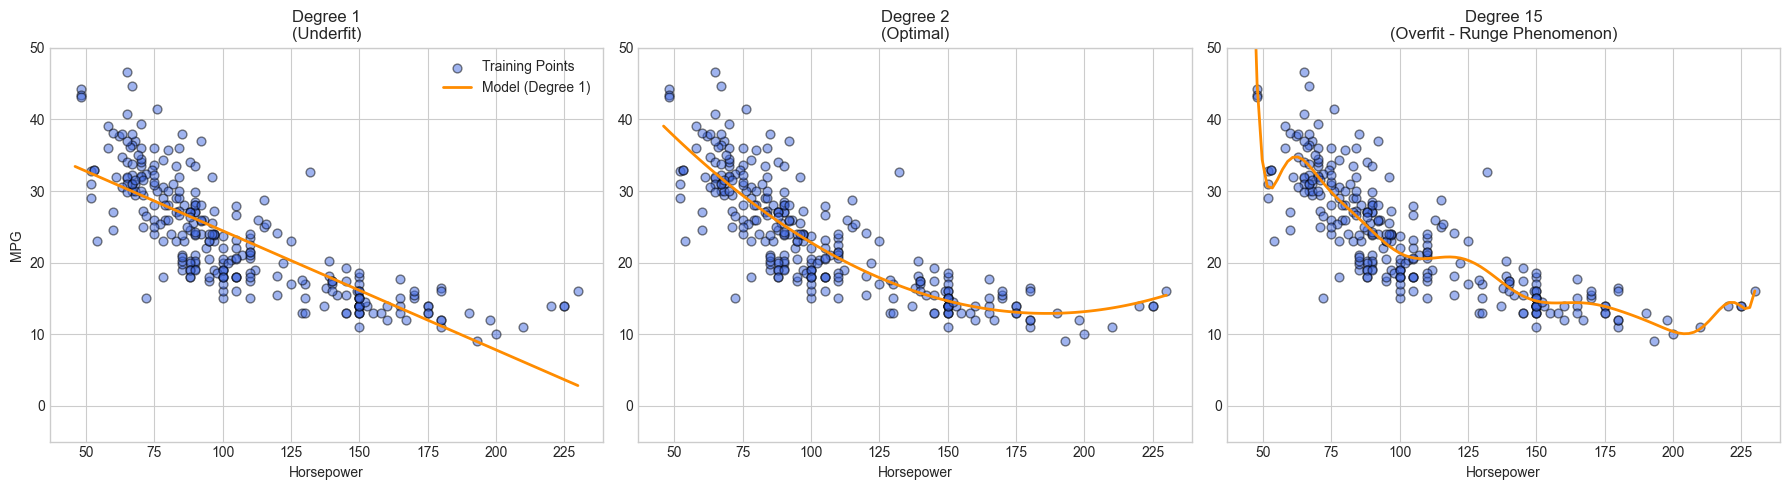

In [13]:
# ============================================================
# SECTION 10 — VISUALIZATION (Underfit vs Optimal vs Overfit)
# ============================================================

degrees_to_plot = [1, 2, 15]
plt.figure(figsize=(18, 5))

for i, d in enumerate(degrees_to_plot):
    ax = plt.subplot(1, 3, i + 1)
    
    # Create and fit a pipeline for the specific degree
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lin_reg', LinearRegression())
    ])
    model.fit(X_train, y_train)
    
    # Predict smoothly across the X domain
    X_smooth = np.linspace(df['horsepower'].min(), df['horsepower'].max(), 100)[:, np.newaxis]
    y_smooth_pred = model.predict(X_smooth)
    
    # Plotting
    plt.scatter(X_train, y_train, edgecolor='black', s=40, color='royalblue', alpha=0.5, label="Training Points")
    plt.plot(X_smooth, y_smooth_pred, color='darkorange', lw=2, label=f"Model (Degree {d})")
    
    # Formatting
    plt.ylim(-5, 50)
    plt.title(f"Degree {d}\n({'Underfit' if d==1 else 'Optimal' if d==2 else 'Overfit - Runge Phenomenon'})")
    if i == 0:
        plt.legend(loc="best")
    plt.xlabel("Horsepower")
    if i == 0:
        plt.ylabel("MPG")

plt.tight_layout()
plt.show()


**Analysis of the plots:**
- **Degree 1:** A rigid straight line. It completely ignores the underlying dynamics of the data and under-predicts MPG for low and high horsepower cars (High Bias).
- **Degree 2:** Beautifully tracks the latent curve, passing smoothly through the data without over-reacting.
- **Degree 15:** Notice how at the far right, the orange line whips wildly up and down to capture a few noisy outlier points, pulling completely away from the overall trend. This oscillation at the edges is exactly Runge's Phenomenon (High Variance).


## 11. Tips & Tricks Summary

- **The Interaction Hack:** In multi-dimensional datasets (like predicting house prices using Income, Age, and Rooms), doing a full degree 3 expansion will create hundreds of useless features like $Rooms^3$. However, `PolynomialFeatures(degree=2, interaction_only=True)` is incredibly useful. It skips the squared terms and ONLY generates the cross-products (e.g., $Income \times Age$), which often carry immense predictive power.
- **The Memory Limit (Curse of Dimensionality):** The formula for the number of features generated by degree $d$ with $n$ original features is roughly $\frac{(n+d)!}{d!n!}$. If you have 100 features and choose degree 4, you generate **4.6 million** new columns. Your kernel will crash.
- **The Kernel Trick Alternative:** If you genuinely need extremely high-dimensional polynomials but can't fit the matrix into RAM, you abandon explicit Polynomial Expansion and use the **Kernel Trick** (e.g., a Polynomial Kernel in a Support Vector Regressor or Ridge). The Kernel trick computes the dot products in the hyper-dimensional space implicitly, bypassing the RAM explosion entirely.


## 12. Conclusion

Polynomial Regression is a masterclass in feature engineering. By simply squaring and cubing our existing data, we unlock the ability for a basic Linear Regression algorithm to model the most complex curves in nature.

However, with great power comes the profound responsibility of managing the Bias-Variance tradeoff. An AI Engineer deploying Polynomial Regression must always rely on rigorous Cross-Validation to select the optimal degree, employ StandardScaling to prevent matrix inversion failures, and strictly guard against the catastrophic failures of extrapolation and Runge's Phenomenon.
